In [1]:
#To implement Logistic Regression on the Iris dataset to predict a binary outcome and visualize the results.
#Dataset Used- 
#Iris Dataset (Scikit-Learn) 
#We convert it into a binary problem: 
#• Class 0 → Setosa 
#• Class 1 → Non-Setosa (Versicolor & Virginica)

In [2]:
#Import Required Libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
 
from sklearn.datasets import load_iris 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
#Load Iris Dataset 
iris = load_iris() 
X = iris.data[:, :2]   # Use first two features for visualization 
y = iris.target

In [4]:
#Convert to Binary Classification 
# Setosa = 0, Non-Setosa = 1 
y = (y != 0).astype(int)

In [5]:
#Data Preprocessing (Feature Scaling) 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

In [6]:
#Train–Test Split 
X_train, X_test, y_train, y_test = train_test_split( 
    X_scaled, y, test_size=0.25, random_state=42 
)

In [7]:
#Train Logistic Regression Model 
model = LogisticRegression() 
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
#Predictions 
y_pred = model.predict(X_test)

In [9]:
#Model Evaluation 
#✔ Accuracy 
print("Accuracy:", accuracy_score(y_test, y_pred)) 
#✔ Confusion Matrix 
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred)) 
#✔ Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[15  0]
 [ 0 23]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        23

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



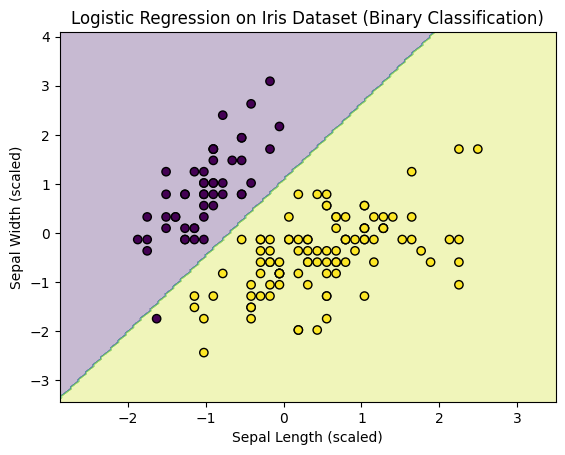

In [10]:
#Visualization (Decision Boundary) 
# Create mesh grid 
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1 
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1 
xx, yy = np.meshgrid( 
np.linspace(x_min, x_max, 200), 
np.linspace(y_min, y_max, 200) 
) 
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) 
Z = Z.reshape(xx.shape) 
# Plot decision boundary 
plt.contourf(xx, yy, Z, alpha=0.3) 
# Scatter plot 
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolor='k') 
plt.xlabel("Sepal Length (scaled)") 
plt.ylabel("Sepal Width (scaled)") 
plt.title("Logistic Regression on Iris Dataset (Binary Classification)") 
plt.show() 